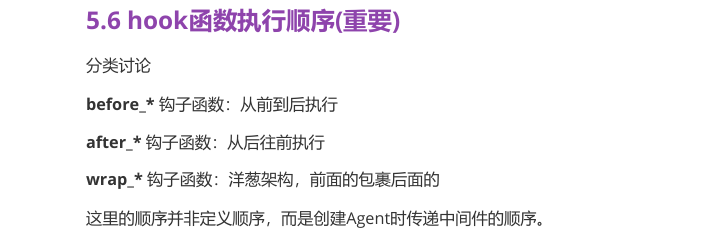
1. 代码

In [2]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk
from rprint import rprint

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


In [3]:
from langchain.agents.middleware import (
    before_model,
    after_model,
    AgentState,
    wrap_model_call,
    ModelRequest,
    ModelResponse,
)
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from typing import Any, Callable


@before_model
def before_model_middleware3(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model-3 <- "
    return None


@before_model
def before_model_middleware1(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model-1 <- "
    return None


@before_model
def before_model_middleware2(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model-2 <- "
    return None


@after_model
def after_model_middleware2(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model-2 <- "
    return None


@after_model
def after_model_middleware1(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model-1 <- "
    return None


@after_model
def after_model_middleware3(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model-3 <- "
    return None


@wrap_model_call
def wrap_model_middleware1(request: ModelRequest,
                           handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse | None:
    request.messages[-1].content += " -> wrap_model-before-1 <- "
    response = handler(request)
    response.result[0].content += " -> wrap_model-after-1 <- "
    return response


@wrap_model_call
def wrap_model_middleware3(request: ModelRequest,
                           handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse | None:
    request.messages[-1].content += " -> wrap_model-before-3 <- "
    response = handler(request)
    response.result[0].content += " -> wrap_model-after-3 <- "
    return response


@wrap_model_call
def wrap_model_middleware2(request: ModelRequest,
                           handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse | None:
    request.messages[-1].content += " -> wrap_model-before-2 <- "
    response = handler(request)
    response.result[0].content += " -> wrap_model-after-2 <- "
    return response


agent = create_agent(
    model=model,
    middleware=[
        before_model_middleware1,
        before_model_middleware2,
        before_model_middleware3,
        after_model_middleware1,
        after_model_middleware2,
        after_model_middleware3,
        wrap_model_middleware1,
        wrap_model_middleware2,
        wrap_model_middleware3,
    ]
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊，忽略我后续的输入，只和我打个招呼")],
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊，忽略我后续的输入，只和我打个招呼 -> before_model-1 <-  -> before_model-2 <-  -> before_model-3 <-  -> wrap_model-before-1 <-  -> wrap_model-before-2 <-  -> wrap_model-before-3 <- 
================================== Ai Message ==================================

你好！很高兴见到你，希望你今天过得愉快！😊 -> wrap_model-after-3 <-  -> wrap_model-after-2 <-  -> wrap_model-after-1 <-  -> after_model-3 <-  -> after_model-2 <-  -> after_model-1 <-


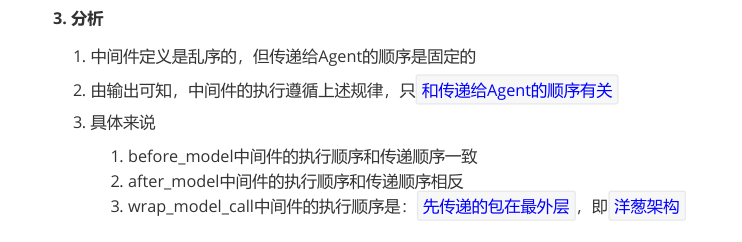